In [1]:
import importlib

from models import edsr
from datasets import rekis
importlib.reload(edsr)
importlib.reload(rekis)

from models.edsr import EDSR
from datasets.rekis import ReKISDataModule

In [2]:
import torch
import lightning

In [3]:
torch.cuda.is_available()

True

In [4]:
lightning.seed_everything(42, workers=True)
rekis_module = ReKISDataModule(32, f'../../rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/')
rekis_module.setup(None)

train_loader = rekis_module.train_dataloader()
val_loader = rekis_module.val_dataloader()

Seed set to 42


In [5]:
torch.set_float32_matmul_precision("high")
trainer = lightning.Trainer(accelerator='gpu', devices=1, max_epochs=5, log_every_n_steps=1)
trainer.fit(EDSR(1, 2), train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | train_metrics | MetricCollection | 0      | train
1 | val_metrics   | MetricCollection | 0      | train
2 | loss          | L1Loss           | 0      | train
3 | head          | Sequential       | 320    | train
4 | body          | Sequential       | 46.2 K | train
5 | tail          | Sequential       | 37.3 K | train
-----------------------------------------------------------
83.8 K    Trainable params
0         Non-trainable params
83.8 K    Total params
0.335     Total estimated model params size (MB)
28        Modules

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


In [7]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs/

In [13]:
checkpoint = "lightning_logs/version_21/checkpoints/epoch=4-step=290.ckpt"
clf = EDSR.load_from_checkpoint(checkpoint).eval()
Y_edsr = torch.cat(trainer.predict(clf, train_loader))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [16]:
x, y = next(iter(train_loader))

In [20]:
x.shape, clf(x).shape, y.shape

(torch.Size([32, 1, 200, 200]),
 torch.Size([32, 1, 400, 400]),
 torch.Size([32, 1, 400, 400]))

In [27]:
clf(x)[0].squeeze().shape

torch.Size([400, 400])

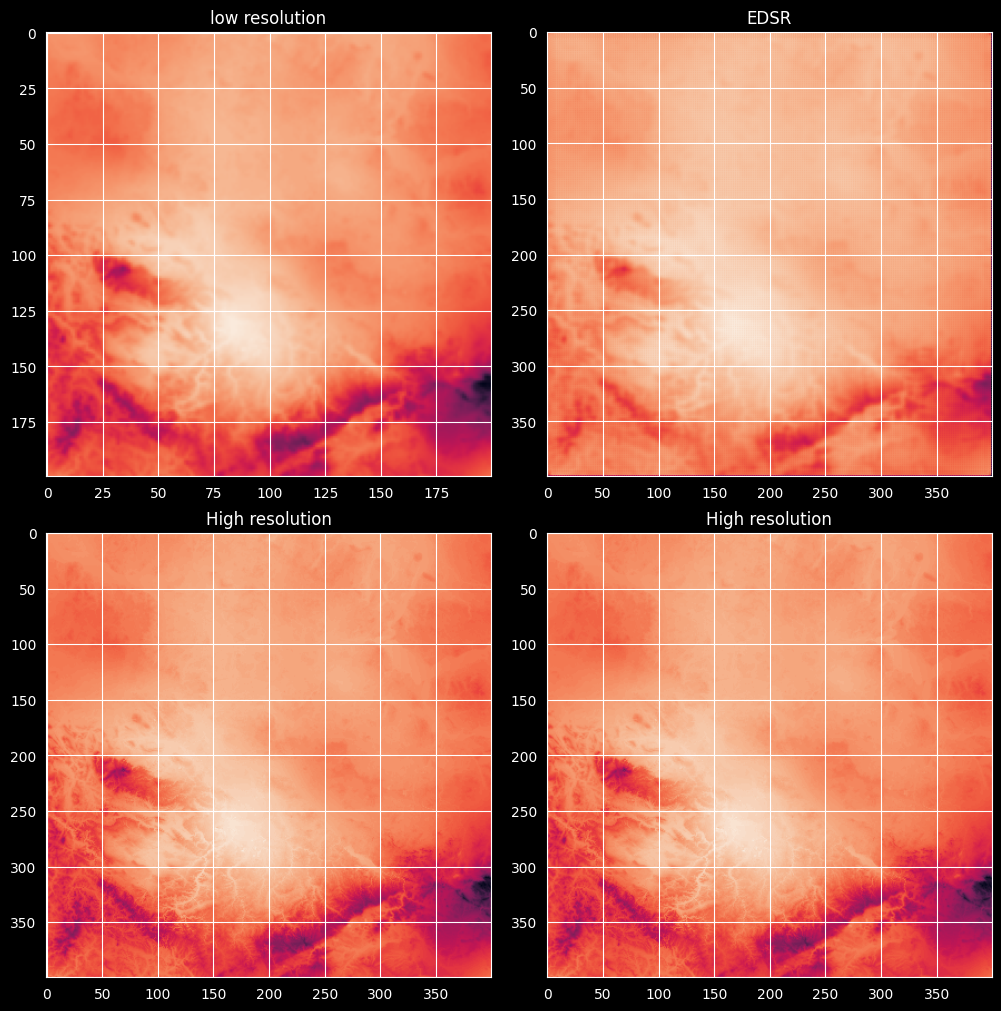

In [30]:
import random
import matplotlib.pyplot as plt

i = random.randint(0, 32)

fig, axes = plt.subplots(ncols=2, nrows=2, constrained_layout=True, figsize=(10, 10))
axes[0, 0].set_title("low resolution")
axes[0, 0].imshow(x[i].squeeze())
axes[0, 1].set_title("EDSR")
with torch.no_grad():
    axes[0, 1].imshow(clf(x)[i].squeeze())
axes[1, 0].set_title("High resolution")
axes[1, 0].imshow(y[i].squeeze())
axes[1, 1].set_title("High resolution")
axes[1, 1].imshow(y[i].squeeze())